# 03. Optimización de la cartera

En el notebook anterior calculé la rentabilidad anual de cada activo y la matriz de covarianzas. Aquí uso esos datos para responder a la pregunta de Markowitz: **¿qué pesos dan el mejor equilibrio entre rentabilidad y riesgo?**

Pasos de este notebook:
1. Cargar los resultados del notebook 02.
2. Comprobar las funciones de cartera con un reparto de pesos iguales.
3. Buscar la cartera de **mínima varianza**.
4. Construir la **frontera eficiente**.

### Carga de datos

Leo la rentabilidad anual y la matriz de covarianzas guardadas en `data/`.

In [53]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Leo lo que guardé en el notebook anterior
cov_anual = pd.read_csv("../data/cov_anual.csv", index_col=0)
rentabilidad_anual = pd.read_csv("../data/rentabilidad_anual.csv", index_col=0).squeeze("columns")

activos = cov_anual.index
n = len(activos)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Funciones de cartera

- `vol_cartera(w, cov)`: volatilidad de la cartera, $\sigma_p = \sqrt{w^\top \Sigma\, w}$
- `rent_cartera(w, mu)`: rentabilidad de la cartera, $\mu_p = w^\top \mu$

Primero las pruebo con una cartera de **pesos iguales** (1/6 en cada activo).

In [54]:
import sys
sys.path.append("..")   # el notebook está en notebooks/, así que subo a la raíz del proyecto

from src.portfolio import vol_cartera, rent_cartera

cov = cov_anual.values
mu = rentabilidad_anual.values

w_igual = np.repeat(1/n, n)
vol_cartera(w_igual, cov), rent_cartera(w_igual, mu)

(np.float64(0.12204498923882974), np.float64(0.09849491550479982))

**Resultado:** la cartera de pesos iguales tiene una rentabilidad anual del **9,85 %** y una volatilidad del **12,20 %**. Este reparto será el punto de comparación para las carteras optimizadas.

### Cartera de mínima varianza

La cartera de **mínima varianza** es la que tiene el menor riesgo posible, sin importar la rentabilidad. Como no hay una fórmula sencilla con restricciones, se la pido a un optimizador (`scipy.optimize.minimize`).

El problema es:

$$\min_w \; w^\top \Sigma\, w \quad \text{sujeto a} \quad \sum_i w_i = 1, \quad 0 \le w_i \le 1$$

- La primera restricción dice que todo el capital está invertido.
- La segunda prohíbe posiciones cortas. w<0


In [55]:
comparacion = pd.DataFrame({
    "Rentabilidad": [rent_cartera(w_igual, mu), rent_cartera(w_min, mu)],
    "Volatilidad":  [vol_cartera(w_igual, cov), vol_cartera(w_min, cov)],
}, index=["Pesos iguales", "Mín. varianza"])

comparacion.round(4)

,Rentabilidad,Volatilidad
Pesos iguales,0.0985,0.1220
Mín. varianza,0.0292,0.0528


In [56]:
from src.portfolio import cartera_min_varianza

w_min = cartera_min_varianza(cov)

pesos = pd.DataFrame({"Pesos iguales": w_igual, " Pesos Mín. varianza": w_min}, index=activos)
pesos.round(3)

,Pesos iguales,Pesos Mín. varianza
AGG,0.167,0.939
EEM,0.167,0.000
EFA,0.167,0.000
GLD,0.167,0.007
SPY,0.167,0.054
VNQ,0.167,0.000


La cartera de mínima varianza tiene una volatilidad del **5,28 %**, frente al 12,20 % de la cartera de pesos iguales. Los pesos se concentran en **[activos con menos volatilidad]**.

El optimizador busca el menor riesgo, así que premia a los activos poco volátiles y poco correlacionados con el resto, como AGG. La rentabilidad es **2,92 %**, menor que la de pesos iguales (9,85 %), así que reducir el riesgo al mínimo tiene un coste. Esto lleva a la frontera eficiente, que busca el mejor equilibrio entre ambas.

### Frontera eficiente

La cartera de mínima varianza minimiza el riesgo sin mirar la rentabilidad. Pero un inversor puede aceptar más riesgo a cambio de más rentabilidad. Por eso, para cada **rentabilidad objetivo** busco los pesos con la menor volatilidad que la consiguen:

$$\min_w \; w^\top \Sigma\, w \quad \text{sujeto a} \quad \sum_i w_i = 1, \quad w^\top \mu = \mu_{objetivo}, \quad 0 \le w_i \le 1$$

Repito el problema para 50 rentabilidades objetivo, desde la de la mínima varianza hasta la del activo más rentable. Los puntos resultantes forman la **frontera eficiente**: ninguna cartera posible ofrece más rentabilidad con el mismo riesgo.

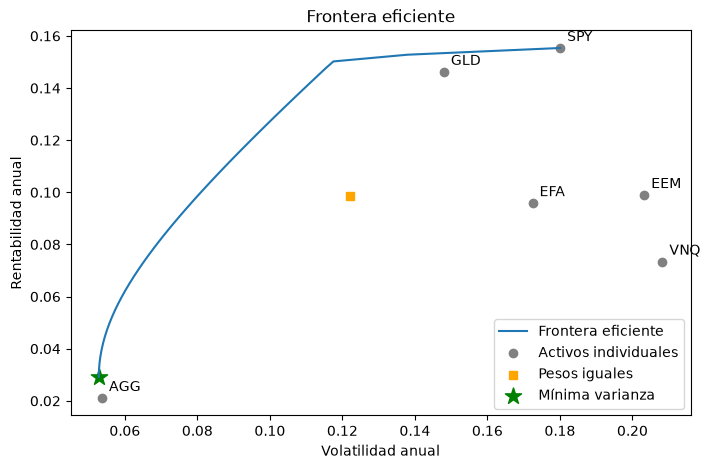

In [57]:
from src.portfolio import frontera_eficiente

rents, vols, pesos_frontera = frontera_eficiente(cov, mu)

vol_activos = np.sqrt(np.diag(cov))     # volatilidad de cada activo por separado

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(vols, rents, label="Frontera eficiente")
ax.scatter(vol_activos, mu, color="gray", label="Activos individuales")
for nombre, x, y in zip(activos, vol_activos, mu):
    ax.annotate(nombre, (x, y), textcoords="offset points", xytext=(5, 5))

ax.scatter(vol_cartera(w_igual, cov), rent_cartera(w_igual, mu),
           marker="s", color="orange", label="Pesos iguales")
ax.scatter(vol_cartera(w_min, cov), rent_cartera(w_min, mu),
           marker="*", s=150, color="green", label="Mínima varianza")

ax.set_xlabel("Volatilidad anual")
ax.set_ylabel("Rentabilidad anual")
ax.set_title("Frontera eficiente")
ax.legend()
plt.show()

- Los activos individuales quedan a la derecha o por debajo de la curva: cualquiera de ellos se puede mejorar combinándolo con otros.
- La cartera de pesos iguales queda dentro de la zona, por debajo de la frontera: con su mismo riesgo había carteras con más rentabilidad.
- La mínima varianza es el punto más a la izquierda de la curva.
- La curva termina en el activo de mayor rentabilidad.